In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11



mu0 = 4 * np.pi * 1e-7  # vacuum permeability [T m / A]
SENSOR_Z_SIGN = -1.0 #convention 

# Wire geometry
WIRE_THETA_DEG =-8.0

# Wire center position in the xy-plane
WIRE_X0_UM = 20.0
WIRE_Y0_UM = 0.0

EFFECTIVE_HEIGHT_UM = 20.0


WIRE_LENGTH_UM = 500.0
WIRE_RADIUS_UM = 10.0

# Upward bend model:
# bend = 0 means straight wire at constant height.
# bend > 0 means the middle of the wire is farther from the NV layer
# than the ends. This matches your idea:
# ends closer to diamond, middle lifted upward.
WIRE_CENTER_RAISE_UM = 0.0

#resolution parameters

N_FILAMENT_POINTS = 401
N_CYLINDER_LENGTH = 151
N_CYLINDER_CROSS = 9

B_COMPONENTS = ["Bx", "By", "Bz"]
CMAP = "seismic"



In [35]:
#Load B_results.csvn+ metadata

B_RESULTS_CSV_PATH = "B_results.csv"

B_df = pd.read_csv(B_RESULTS_CSV_PATH)
B_df = B_df.sort_values(["row", "col"]).reset_index(drop=True)

grid_size = int(np.sqrt(len(B_df)))
if grid_size * grid_size != len(B_df):
    raise ValueError("B_results.csv does not contain a square grid.")

x_grid_um = B_df["x_um"].to_numpy().reshape(grid_size, grid_size)
y_grid_um = B_df["y_um"].to_numpy().reshape(grid_size, grid_size)

extent_um = [
    np.nanmin(x_grid_um),
    np.nanmax(x_grid_um),
    np.nanmin(y_grid_um),
    np.nanmax(y_grid_um),
]

B_pos_meas = np.stack([
    B_df["Bx_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_pos_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_neg_meas = np.stack([
    B_df["Bx_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_neg_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_odd_meas = np.stack([
    B_df["Bx_odd_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_odd_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_odd_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_even_meas = np.stack([
    B_df["Bx_even_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_even_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_even_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)


METADATA_CSV_PATH = "B_results_metadata.csv"

metadata_df = pd.read_csv(METADATA_CSV_PATH)

def get_metadata_value(key, default=None, cast=float):
    matches = metadata_df.loc[metadata_df["key"] == key, "value"]

    if len(matches) == 0:
        print(f"Metadata key '{key}' not found. Using default: {default}")
        return default

    value = matches.iloc[0]

    if cast is None:
        return value

    try:
        return cast(value)
    except Exception:
        print(f"Could not cast metadata key '{key}' = {value}. Using default: {default}")
        return default


PULSE_AMPLITUDE_mV = get_metadata_value("pulse_amplitude_mV", default=10.0, cast=float)
PULSE_AMPLITUDE_V = get_metadata_value("pulse_amplitude_V", default=PULSE_AMPLITUDE_mV * 1e-3, cast=float)

I_POS_mA = get_metadata_value("current_pos_mA", default=2.0, cast=float)
I_NEG_mA = get_metadata_value("current_neg_mA", default=-2.0, cast=float)

I_POS_A = I_POS_mA * 1e-3
I_NEG_A = I_NEG_mA * 1e-3

EFFECTIVE_HEIGHT_UM = get_metadata_value(
    "effective_wire_height_um_for_simulation",
    default=20.0,
    cast=float,
)




## wire models biot approx and cylindrical wire 2 functions


SI units internally:
   x,y,z in meters
   I in amperes
   B in tesla 
 Output:  B in nT


In [36]:
#helper fucntiosn to bend that bitch

def bent_wire_height_um(s_um, base_height_um, length_um, center_raise_um):
    parabola = 1.0 - (2.0 * s_um / length_um)**2
    parabola = np.maximum(parabola, 0.0)
    return base_height_um + center_raise_um * parabola

In [37]:
# ============================================================
# Cell 7
# Infinite tilted wire Biot-Savart model
# ============================================================
# Wire direction:
#   theta = 0 deg means current flows along +y.
#   theta > 0 deg means current tilts toward +x as y increases.
#
# NV plane:
#   z = 0
#
# Wire:
#   centered at (WIRE_X0_UM, WIRE_Y0_UM)
#   height = EFFECTIVE_HEIGHT_UM
# ============================================================

def simulate_infinite_wire(
    x_um,
    y_um,
    I_A,
    height_um,
    x0_um=0.0,
    y0_um=0.0,
    theta_deg=0.0,
):
    theta = np.deg2rad(theta_deg)

    # Unit vector along the wire/current direction
    u = np.array([
        np.sin(theta),
        np.cos(theta),
        0.0,
    ])

    # Observation points in meters
    X = x_um * 1e-6
    Y = y_um * 1e-6
    Z = np.zeros_like(X)

    # One point on the infinite wire
    r0 = np.array([
        x0_um * 1e-6,
        y0_um * 1e-6,
        height_um * 1e-6,
        SENSOR_Z_SIGN * height_um * 1e-6,  
    ])

    Rx = X - r0[0]
    Ry = Y - r0[1]
    Rz = Z - r0[2]

    # Perpendicular vector from wire to observation point
    R_dot_u = Rx * u[0] + Ry * u[1] + Rz * u[2]

    Rpx = Rx - R_dot_u * u[0]
    Rpy = Ry - R_dot_u * u[1]
    Rpz = Rz - R_dot_u * u[2]

    rho2 = Rpx**2 + Rpy**2 + Rpz**2
    rho2 = np.where(rho2 < 1e-30, 1e-30, rho2)

    # Direction from Biot-Savart:
    # B is proportional to u x r_perp
    cross_x = u[1] * Rpz - u[2] * Rpy
    cross_y = u[2] * Rpx - u[0] * Rpz
    cross_z = u[0] * Rpy - u[1] * Rpx

    prefactor = mu0 * I_A / (2 * np.pi)

    Bx_T = prefactor * cross_x / rho2
    By_T = prefactor * cross_y / rho2
    Bz_T = prefactor * cross_z / rho2

    B_nT = 1e9 * np.stack([Bx_T, By_T, Bz_T], axis=0)

    return B_nT


# ============================================================
# Model 2: finite cylindrical wire with optional upward bend
# ============================================================
# This model numerically integrates Biot-Savart over a finite cylindrical wire.
#
# The current flows along a tilted wire in the x-y plane.
# The wire can bend upward in z:
#   ends at height_um,
#   middle at height_um + center_raise_um.
#
# Output:
#   B_nT with shape (3, Ny, Nx), ordered as [Bx, By, Bz]

def simulate_finite_cylindrical_wire(
    x_um,
    y_um,
    I_A,
    height_um,
    radius_um=10.0,
    length_um=500.0,
    x0_um=0.0,
    y0_um=0.0,
    theta_deg=0.0,
    center_raise_um=0.0,
    n_length=151,
    n_cross=9,
):
    theta = np.deg2rad(theta_deg)

    # Unit vector along the wire in the xy-plane
    ux = np.sin(theta)
    uy = np.cos(theta)
    uz = 0.0

    # In-plane perpendicular direction across wire diameter
    px = uy
    py = -ux
    pz = 0.0

    # Observation points: NV plane at z = 0
    X = x_um * 1e-6
    Y = y_um * 1e-6
    Z = np.zeros_like(X)

    radius_m = radius_um * 1e-6
    length_m = length_um * 1e-6

    area_m2 = np.pi * radius_m**2
    J_A_per_m2 = I_A / area_m2

    # Points along wire
    s_um = np.linspace(-length_um / 2, length_um / 2, n_length)
    ds_m = (s_um[1] - s_um[0]) * 1e-6

    # Cross-section sampling
    q_um = np.linspace(-radius_um, radius_um, n_cross)
    zc_um = np.linspace(-radius_um, radius_um, n_cross)

    cross_offsets = []
    for q in q_um:
        for zc in zc_um:
            if q**2 + zc**2 <= radius_um**2:
                cross_offsets.append((q, zc))

    cross_offsets = np.array(cross_offsets)

    if len(cross_offsets) == 0:
        raise ValueError("No cross-section points selected. Increase n_cross.")

    # Each sampled cross-section point represents equal area
    dA_m2 = area_m2 / len(cross_offsets)

    Bx_T = np.zeros_like(X, dtype=float)
    By_T = np.zeros_like(X, dtype=float)
    Bz_T = np.zeros_like(X, dtype=float)

    prefactor = mu0 / (4 * np.pi)

    for s in s_um:
        z_center_um = bent_wire_height_um(
            s_um=s,
            base_height_um=height_um,
            length_um=length_um,
            center_raise_um=center_raise_um,
        )

        for q, zc in cross_offsets:
            # Position of current element
            xs_um = x0_um + s * ux + q * px
            ys_um = y0_um + s * uy + q * py
            zs_um = z_center_um + zc

            xs = xs_um * 1e-6
            ys = ys_um * 1e-6
            zs = zs_um * 1e-6

            Rx = X - xs
            Ry = Y - ys
            Rz = Z - zs

            R2 = Rx**2 + Ry**2 + Rz**2
            R = np.sqrt(R2)
            R3 = np.where(R < 1e-15, 1e-45, R**3)

            # Current element:
            # J dV = J * dA * ds * direction
            JdVx = J_A_per_m2 * dA_m2 * ds_m * ux
            JdVy = J_A_per_m2 * dA_m2 * ds_m * uy
            JdVz = J_A_per_m2 * dA_m2 * ds_m * uz

            # JdV x R
            cross_x = JdVy * Rz - JdVz * Ry
            cross_y = JdVz * Rx - JdVx * Rz
            cross_z = JdVx * Ry - JdVy * Rx

            Bx_T += prefactor * cross_x / R3
            By_T += prefactor * cross_y / R3
            Bz_T += prefactor * cross_z / R3

    return 1e9 * np.stack([Bx_T, By_T, Bz_T], axis=0)

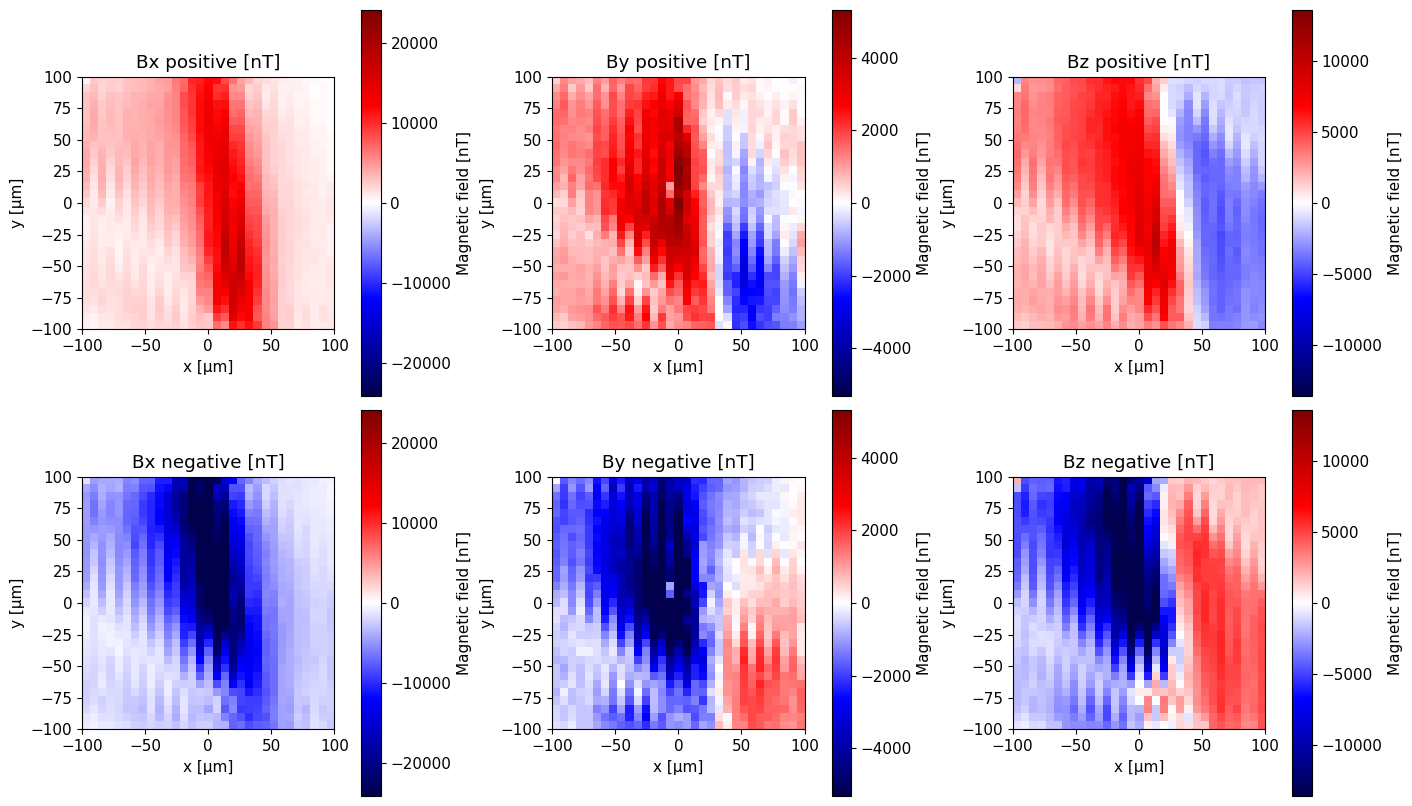

In [38]:


fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
for i, comp in enumerate(B_COMPONENTS):
    pos_map = B_pos_meas[i]
    neg_map = B_neg_meas[i]

    lim = max(
        np.nanpercentile(np.abs(pos_map), 95),
        np.nanpercentile(np.abs(neg_map), 95),
    )

    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im0 = axes[0, i].imshow(
        pos_map,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[0, i].set_title(f"{comp} positive [nT]")
    axes[0, i].set_xlabel("x [µm]")
    axes[0, i].set_ylabel("y [µm]")
    plt.colorbar(im0, ax=axes[0, i], label="Magnetic field [nT]")

    im1 = axes[1, i].imshow(
        neg_map,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[1, i].set_title(f"{comp} negative [nT]")
    axes[1, i].set_xlabel("x [µm]")
    axes[1, i].set_ylabel("y [µm]")
    plt.colorbar(im1, ax=axes[1, i], label="Magnetic field [nT]")

plt.show()

In [39]:
# ============================================================
# Cell 8
# Simulate POS and NEG magnetic fields using the same current
# values as saved in the pulse-file metadata
# ============================================================

# Infinite wire
B_pos_sim_infinite = simulate_infinite_wire(
    x_grid_um,
    y_grid_um,
    I_A=I_POS_A,
    height_um=EFFECTIVE_HEIGHT_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
)

B_neg_sim_infinite = simulate_infinite_wire(
    x_grid_um,
    y_grid_um,
    I_A=I_NEG_A,
    height_um=EFFECTIVE_HEIGHT_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
)


# Finite cylindrical wire
# This assumes your earlier notebook already defined simulate_cylindrical_wire.
# If your function has a slightly different name, replace the function name here.

B_pos_sim_cylinder = simulate_finite_cylindrical_wire(
    x_grid_um,
    y_grid_um,
    I_A=I_POS_A,
    height_um=EFFECTIVE_HEIGHT_UM,
    radius_um=WIRE_RADIUS_UM,
    length_um=WIRE_LENGTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
    center_raise_um=0.0,
    n_length=N_CYLINDER_LENGTH,
    n_cross=N_CYLINDER_CROSS,
)

B_neg_sim_cylinder = simulate_finite_cylindrical_wire(
    x_grid_um,
    y_grid_um,
    I_A=I_NEG_A,
    height_um=EFFECTIVE_HEIGHT_UM,
    radius_um=WIRE_RADIUS_UM,
    length_um=WIRE_LENGTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
    center_raise_um=0.0,
    n_length=N_CYLINDER_LENGTH,
    n_cross=N_CYLINDER_CROSS,
)

print("Simulated fields using metadata current and effective height")
print("-----------------------------------------------------------")

for model_name, Bpos, Bneg in [
    ("infinite_wire", B_pos_sim_infinite, B_neg_sim_infinite),
    ("finite_cylinder", B_pos_sim_cylinder, B_neg_sim_cylinder),
]:
    print(f"\n{model_name}")
    for i, comp in enumerate(B_COMPONENTS):
        print(f"{comp}_pos p95 abs [nT] = {np.nanpercentile(np.abs(Bpos[i]), 95):.3f}")
        print(f"{comp}_neg p95 abs [nT] = {np.nanpercentile(np.abs(Bneg[i]), 95):.3f}")

Simulated fields using metadata current and effective height
-----------------------------------------------------------

infinite_wire
Bx_pos p95 abs [nT] = 18431.723
Bx_neg p95 abs [nT] = 18431.723
By_pos p95 abs [nT] = 2590.410
By_neg p95 abs [nT] = 2590.410
Bz_pos p95 abs [nT] = 9926.372
Bz_neg p95 abs [nT] = 9926.372

finite_cylinder
Bx_pos p95 abs [nT] = 18346.425
Bx_neg p95 abs [nT] = 18346.425
By_pos p95 abs [nT] = 2578.422
By_neg p95 abs [nT] = 2578.422
Bz_pos p95 abs [nT] = 9843.036
Bz_neg p95 abs [nT] = 9843.036


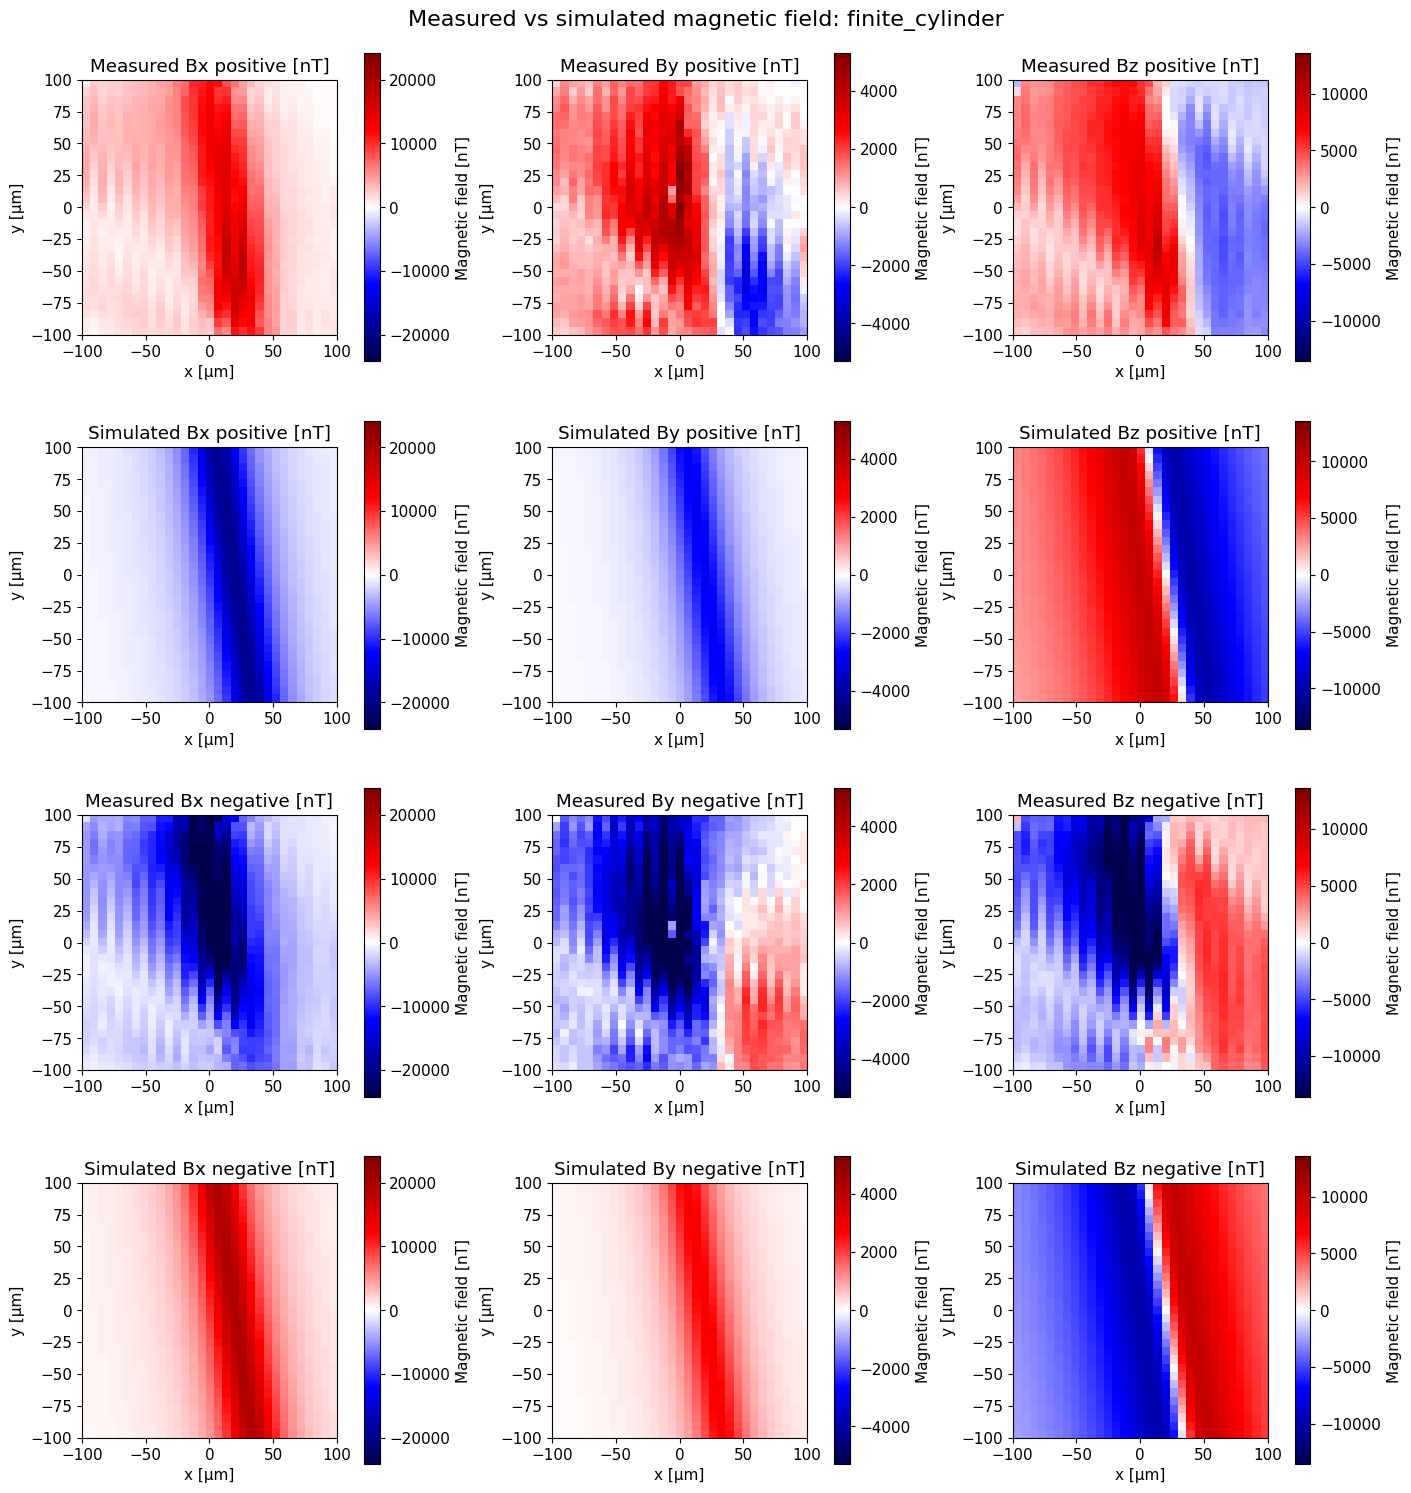

In [40]:
# ============================================================
# Cell 9
# Direct comparison: measured pulse-file B maps vs simulation
# ============================================================
# This compares the same quantities:
#
#   measured POS  vs simulated POS
#   measured NEG  vs simulated NEG
#
# No odd/even extraction.
# No fitted scaling.
# No normalization.
# ============================================================

MODEL_TO_PLOT = "finite_cylinder"
# Options:
#   "infinite_wire"
#   "finite_cylinder"

if MODEL_TO_PLOT == "infinite_wire":
    B_pos_sim = B_pos_sim_infinite
    B_neg_sim = B_neg_sim_infinite
elif MODEL_TO_PLOT == "finite_cylinder":
    B_pos_sim = B_pos_sim_cylinder
    B_neg_sim = B_neg_sim_cylinder
else:
    raise ValueError("MODEL_TO_PLOT must be 'infinite_wire' or 'finite_cylinder'.")

fig, axes = plt.subplots(4, 3, figsize=(14, 15), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    measured_pos = B_pos_meas[i]
    measured_neg = B_neg_meas[i]
    simulated_pos = B_pos_sim[i]
    simulated_neg = B_neg_sim[i]

    lim = max(
        np.nanpercentile(np.abs(measured_pos), 95),
        np.nanpercentile(np.abs(measured_neg), 95),
        np.nanpercentile(np.abs(simulated_pos), 95),
        np.nanpercentile(np.abs(simulated_neg), 95),
    )

    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    maps = [
        (measured_pos, f"Measured {comp} positive [nT]"),
        (simulated_pos, f"Simulated {comp} positive [nT]"),
        (measured_neg, f"Measured {comp} negative [nT]"),
        (simulated_neg, f"Simulated {comp} negative [nT]"),
    ]

    for row_i, (data, title) in enumerate(maps):
        im = axes[row_i, i].imshow(
            data,
            extent=extent_um,
            origin="lower",
            aspect="equal",
            cmap=CMAP,
            vmin=-lim,
            vmax=lim,
        )

        axes[row_i, i].set_title(title)
        axes[row_i, i].set_xlabel("x [µm]")
        axes[row_i, i].set_ylabel("y [µm]")
        plt.colorbar(im, ax=axes[row_i, i], label="Magnetic field [nT]")

fig.suptitle(f"Measured vs simulated magnetic field: {MODEL_TO_PLOT}", fontsize=16)
plt.show()